In this notebook, we consider the results for the squared exponential correlation function.

In [10]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import torch
import scipy
import scipy.linalg
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process

In [11]:
# crossing_type = "upcrossing"  
# crossing_type = "downcrossing"
crossing_type = "crossing"
ModelClass = formula.GaussianUpCrossingsDimless

mean_rate_method = f"{crossing_type}_mean_rate"
fano_method = f"{crossing_type}_fano_factor_CLT"

In [12]:
# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
sigma = 1.0 # Standard deviation (amplitude) of the process

In [13]:
num_points_taus = 50
taus = torch.linspace(0.01, 1.0, num_points_taus)

num_points_zeta = 50
zeta = torch.linspace(0.0, 3.0, num_points_zeta) 

mean_rates = torch.zeros(num_points_taus, num_points_zeta)
fano_factors = torch.zeros(num_points_taus, num_points_zeta)

In [14]:
for i in range(num_points_taus):
    for j in range(num_points_zeta):
        u = zeta[j] * sigma
        tau = taus[i]
        model = ModelClass(r_func=process.r_squared_exp, u=u, tau=tau, sigma=sigma)
        mean_rates[i, j] = getattr(model, mean_rate_method)()
        fano_factors[i, j] = getattr(model, fano_method)(epsilon_left=1e-2, epsilon_right=1e-5)

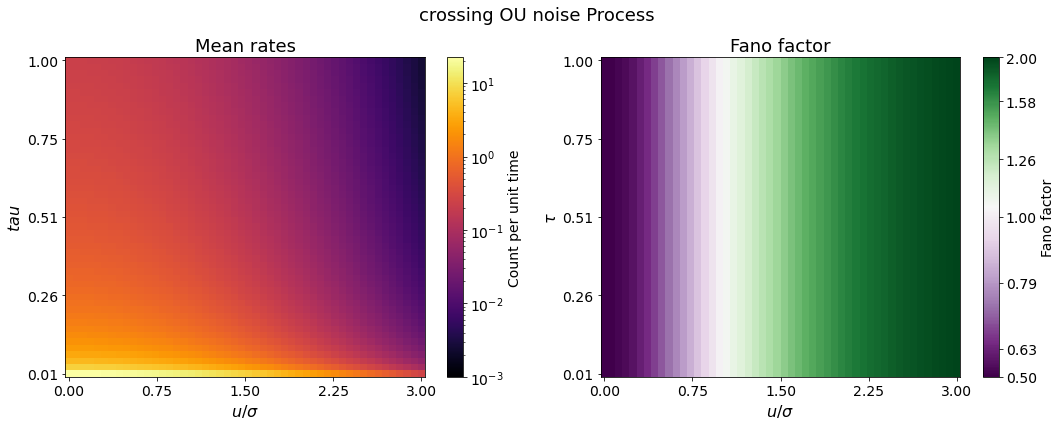

In [16]:
# -----------------------
# Plotting parameters
# -----------------------
cmap_mean = 'inferno'
cmap_fano = 'PRGn'
label_fontsize = 16
tick_fontsize = 14
title_fontsize = 18
cbar_labelsize = 14

# Number of ticks to display on each axis (independent of underlying spacing)
num_ticks = 5
x_ticks = np.linspace(zeta.min(), zeta.max(), num_ticks)
y_ticks = np.linspace(taus.min(), taus.max(), num_ticks)

# -----------------------
# Create the figure and subplots

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- Left subplot: Mean Rates with Linear Scale ----
# Set a small threshold epsilon for the lower bound (adjust as needed)
epsilon = 1e-3
# Clip the data so that no value is below epsilon
adjusted_mean_rates = np.clip(mean_rates, epsilon, None)
# Set up LogNorm with vmin set to epsilon and vmax as the maximum of the adjusted data
log_norm = LogNorm(vmin=epsilon, vmax=adjusted_mean_rates.max())

pc0 = axes[0].pcolormesh(zeta, taus, adjusted_mean_rates, shading='auto',
                         cmap=cmap_mean, norm=log_norm)
cbar0 = fig.colorbar(pc0, ax=axes[0])
cbar0.set_label("Count per unit time", fontsize=cbar_labelsize)
cbar0.ax.tick_params(labelsize=tick_fontsize)

axes[0].set_xlabel(r'$u/\sigma$', fontsize=label_fontsize)
axes[0].set_ylabel(r'$tau$', fontsize=label_fontsize)
axes[0].set_title('Mean rates', fontsize=title_fontsize)
axes[0].set_xticks(x_ticks)
axes[0].set_yticks(y_ticks)
axes[0].set_xticklabels([f"{val:.2f}" for val in x_ticks], fontsize=tick_fontsize)
axes[0].set_yticklabels([f"{val:.2f}" for val in y_ticks], fontsize=tick_fontsize)

# -----------------------
# Right subplot: Fano Factors
# -----------------------
# Plot Fano factors on a linear scale
fano_log = np.log10(fano_factors)

# Use the custom normalization, setting the midpoint at 0 (log10(1))
norm_fano = utils.MidpointNormalize(vmin=fano_log.min(), vmax=fano_log.max(), midpoint=0)

pc1 = axes[1].pcolormesh(zeta, taus, fano_log, shading='auto',
                         cmap=cmap_fano, norm=norm_fano)
cbar1 = fig.colorbar(pc1, ax=axes[1])
cbar1.set_label("Fano factor", fontsize=cbar_labelsize)
cbar1.ax.tick_params(labelsize=tick_fontsize)

# Adjust colorbar tick labels to show original Fano factor values.
def log_tick_formatter(x, pos):
    return f"{10**x:.2f}"
cbar1.formatter = mticker.FuncFormatter(log_tick_formatter)
cbar1.update_ticks()

axes[1].set_xlabel(r'$u/\sigma$', fontsize=label_fontsize)
axes[1].set_ylabel(r'$\tau$', fontsize=label_fontsize)
axes[1].set_title('Fano factor', fontsize=title_fontsize)
axes[1].set_xticks(x_ticks)
axes[1].set_yticks(y_ticks)
axes[1].set_xticklabels([f"{val:.2f}" for val in x_ticks], fontsize=tick_fontsize)
axes[1].set_yticklabels([f"{val:.2f}" for val in y_ticks], fontsize=tick_fontsize)

# in title for both plots add crossing type
fig.suptitle(f"{crossing_type} OU noise Process", fontsize=title_fontsize)

plt.tight_layout()
plt.show()

In [18]:
model = ModelClass(r_func=process.r_squared_exp, u=0.0, tau=1.0, sigma=sigma)
print(getattr(model, fano_method)(epsilon_left=1e-2, epsilon_right=1e-5))

tensor(0.5718)


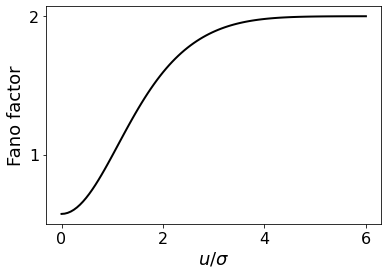

In [19]:
# plotting the fano factor curve as a function of u for any tau
zeta = torch.linspace(0.0, 6.0, 100)
fano_factors = torch.zeros_like(zeta)
for i in range(len(zeta)):
    model = ModelClass(r_func=process.r_squared_exp, u=zeta[i] * sigma, tau=1.0, sigma=sigma)
    fano_factors[i] = getattr(model, fano_method)(epsilon_left=1e-2, epsilon_right=1e-5)

plt.plot(zeta, fano_factors, linewidth=2, color='k')
plt.xlabel(r'$u/\sigma$')
plt.ylabel('Fano factor')

plt.xlabel(r'$u/\sigma$', fontsize=18)
plt.ylabel('Fano factor', fontsize=18)

ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=16)

max_xticks = 5  # Maximum number of tick intervals on x-axis
max_yticks = 5  # Maximum number of tick intervals on y-axis
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=max_xticks, integer=True))
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=max_yticks, integer=True))
plt.show()